In [2]:
import pandas as pd

In [3]:
# Analyze Sales vs every categorical column using groupby
# df.groupby('City')['Sales'].agg(['mean','median','std','count']). Do this for City, Gender,
# Product line, Customer type, Payment.

df = pd.read_csv("SuperMarket Analysis.csv")

# List of categorical columns to analyze against Sales
categorical_cols = ['City', 'Gender', 'Product line', 'Customer type', 'Payment']


# Dictionary to store the results

# A dictionary stores data in key: value pairs, which will allow you to quickly look up the results
# for a specific column later (e.g., groupby_results['City']).
groupby_results = {}



# Loop through each column and apply the aggregation
for col in categorical_cols:
    print(f"--- Sales Analysis by {col} ---")

# Perform groupby and aggregate mean, median, std, and count
    
# .groupby(col): Yeh function data ko us column ke mutabiq alag alag groups (hisson) mein baant deta hai. 
# Agar col 'City' hai, toh yeh Karachi, Lahore, Islamabad wagera ke alag alag groups bana dega.

# ['Sales']: This filters your grouped buckets. It tells Pandas: "Now that the rows are grouped,
# look only at the values inside the 'Sales' column."   

# .agg(...): Short for aggregate. This method runs math functions over the grouped data buckets. 
    
# ['mean', 'median', 'std', 'count']: A list of string commands passed to .agg(). Pandas translates 
# these into specific math calculations:    
    analysis = df.groupby(col)['Sales'].agg(['mean', 'median', 'std', 'count'])

    groupby_results[col] = analysis

# Hum ne jo abhi calculation kar ke analysis nikala hai, use hum apni khali dictionary (groupby_results) 
# mein us column ke naam ke tahat save kar rahe hain. Taake baad mein agar hamein 'City' ya 'Gender' ka 
# result chahiye ho, toh hum wahan se nikal sakein.
#     groupby_results[col] = analysis
    
    print(analysis)
    print("\n")



# Save each analysis to a separate CSV file
    # filename = f"sales_by_{col.lower().replace(' ', '_')}.csv"
    # analysis.to_csv(filename)

--- Sales Analysis by City ---
                 mean     median         std  count
City                                               
Mandalay   319.872506  252.88200  242.447565    332
Naypyitaw  337.099715  271.41975  263.160870    328
Yangon     312.354031  240.82800  231.640025    340


--- Sales Analysis by Gender ---
              mean   median         std  count
Gender                                        
Female  340.931414  284.193  251.613340    571
Male    299.055738  214.746  236.224685    429


--- Sales Analysis by Product line ---
                              mean     median         std  count
Product line                                                    
Electronic accessories  319.632538  241.21650  245.945626    170
Fashion accessories     305.089298  211.64850  243.564130    178
Food and beverages      322.671517  252.48825  247.157780    174
Health and beauty       323.643020  272.30700  237.538815    152
Home and lifestyle      336.636956  258.18975  254.6006

In [4]:
# Build a crosstab: Customer type vs Payment method
# pd.crosstab(df['Customer type'], df['Payment'], values=df['Sales'], aggfunc='mean').round(2)
# — shows average spend for every combination.


# yeh pandas ka Crosstab (Cross Tabulation) function istemal kar raha hai. Yeh tab use hota hai jab
# aap do categorical columns ko aamne-saamne rakh kar (Matrix/Table ki shakal mein) unke beech ka 
# talluq dekhna chahte hain.



import pandas as pd

# 1. Crosstab banana aur values ko round karna

# Yahan df['Customer type'] likha hai, toh table ke left side par rows ke naam honge (jaise: Member aur Normal).

# df['Payment'] (Doosra Parameter / Columns)
# crosstab ke andar jo aap doosri cheez likhte hain, woh table ke Columns (khari lines) banti hain.
# Yahan df['Payment'] likha hai, toh table ke upar columns ke naam honge (jaise: Cash, Credit card, aur Ewallet).


# . values=df['Sales']
# values: Iska matlab hai ke table ke dabbon (cells) ke andar kaun sa numeric data bharna hai.
# Agar aap yeh nahi likhenge, toh crosstab sirf yeh ginega (count) ke kitni baar koi cheez aayi hai.
# Lekin yahan hum ne pandas ko bataya ke dabbon ke andar 'Sales' ki raqam (amount) rakho


# aggfunc='mean'
# aggfunc: Yeh 'Aggregation Function' ka chota lafz hai. Iska matlab hai ke jab Row (Customer type)
# aur Column (Payment) aapas mein milenge, toh unke andar majood 'Sales' ke sath kya calculation karni hai?
    
crosstab_result = pd.crosstab(
    df['Customer type'], 
    df['Payment'], 
    values=df['Sales'], 
    aggfunc='mean'
).round(2)

# 2. Result ko screen par print karna
print("--- Average Spend: Customer Type vs Payment Method ---")
print(crosstab_result)

# 3. (Optional) Agar aap is table ko Excel ya CSV mein save karna chahein
# crosstab_result.to_csv('customer_payment_crosstab.csv')

--- Average Spend: Customer Type vs Payment Method ---
Payment          Cash  Credit card  Ewallet
Customer type                              
Member         335.03       339.73   332.46
Normal         315.00       300.30   302.86


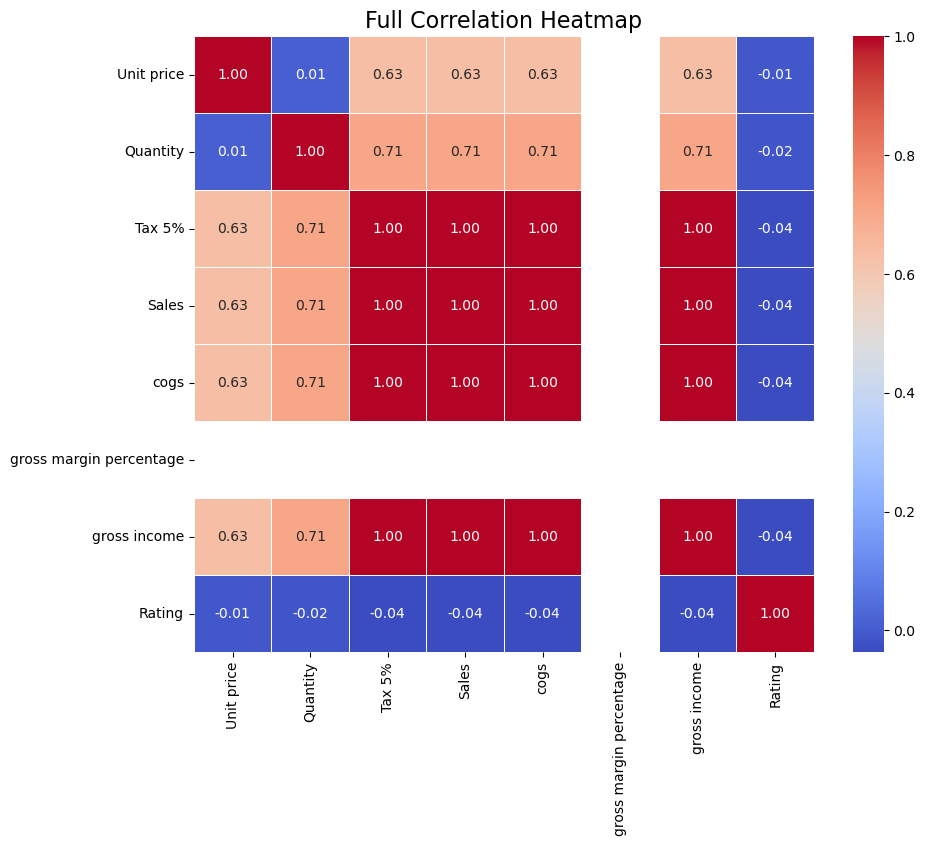

In [5]:
# Build a full correlation heatmap — but this time interpret it
# After plotting, write: which two variables are most correlated? Why does Tax 5%
# correlate perfectly with Sales? What does that tell you about the data?

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sirf numeric columns ko alag karna (kyon ke correlation sirf numbers ka nikalta hai)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Correlation Matrix banana
correlation_matrix = numeric_df.corr()

# 3. Heatmap plot karna
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 4. Title lagana
plt.title('Full Correlation Heatmap', fontsize=16)
plt.show()









# 1. Which two variables are most correlated? (Sab se zyada correlation kin do variables mein hai?)

# ANS Heatmap ke mutabiq, Tax 5% (ya VAT), Gross income, aur Total / Sales ke darmiyan sab se zyada correlation hai.
#     Inka correlation score 1.00 (Perfect Positive Correlation) hai.

# Inke alawa, agar hum aam variables ko dekhein toh Quantity (cheezon ki taudad) aur Sales ke darmiyan kafi strong
# positive correlation hota hai, kyun ke jitni zyada cheezein bikengi, sales utni hi barhegi.




# 2. Why does Tax 5% correlate perfectly with Sales? (Tax 5% ka Sales ke sath bilkul perfect (1.00) correlation kyun hai?)

# AnsTax 5% aur Sales ka aapas mein perfect 1.00 correlation is liye hai kyun ke Tax direct Sales ki raqam par depend karta hai
# aur yeh ek fixed formula se nikalta hai.Mathematic formula yeh hai:$$\text{Tax 5\%} = \text{Sales} \times 0.05$$Jab ek variable
# doosre variable ka direct percentage ya multiple ho, toh unka correlation hamesha 1.00 aata hai. Iska matlab hai ke agar Sales barhegi,
# toh tax bhi bilkul usi raftar (proportion) se barhega. Agar Sales double hogi, toh tax bhi double ho jayega.






# 3. What does that tell you about the data? (Is se aapko data ke baare mein kya pata chalta hai?)
# Yeh cheez hamein data ke baare mein do ahem baatein batati hai:

# Data Redundancy (Faltu Data): Is se pata chalta hai ke hamare data mein kuch columns aisi hain jo koi nayi information nahi de rahin.
# Agar hamare paas Sales majood hai, toh Tax 5% ya Gross income ka column machine learning model ke liye bilkul bekaar (redundant) hai,
# kyun ke woh ek hi baat ko doosre tareeqe se bata rahe hain.

# Feature Selection: Jab hum is data par koi prediction model banayenge, toh hamein in teeno columns (Sales, Tax 5%, Gross income) mein
# se sirf ek ko rakhna chahiye aur baqi ko drop kar dena chahiye. Agar sab ko shamil rakha toh model mein Multicollinearity ka masla paida
# ho jayega, jis se model confuse ho sakta hai.

In [6]:
# cogs ka matlab hota hai "Beche gaye maal ki asli keemat" (yaani woh maal dukandar ko khud kitne ka para tha).
# Supermarket ke data mein aksar profit margin bilkul fixed hota hai (jaise har cheez par 5% ya 10% munafa rakh
# kar bechna). Jab margin fixed ho, toh formula yeh banta hai:$$\text{Sales} = \text{cogs} + \text{Profit Margin}$$



# Jab do ya do se zyada variables ka correlation 1.00 ya uske bilkul qareeb ho (jaise aap ke map mein Sales,
# Tax 5%, cogs, aur gross income hain), toh isay Machine Learning aur Statistics mein Multicollinearity kehte hain.




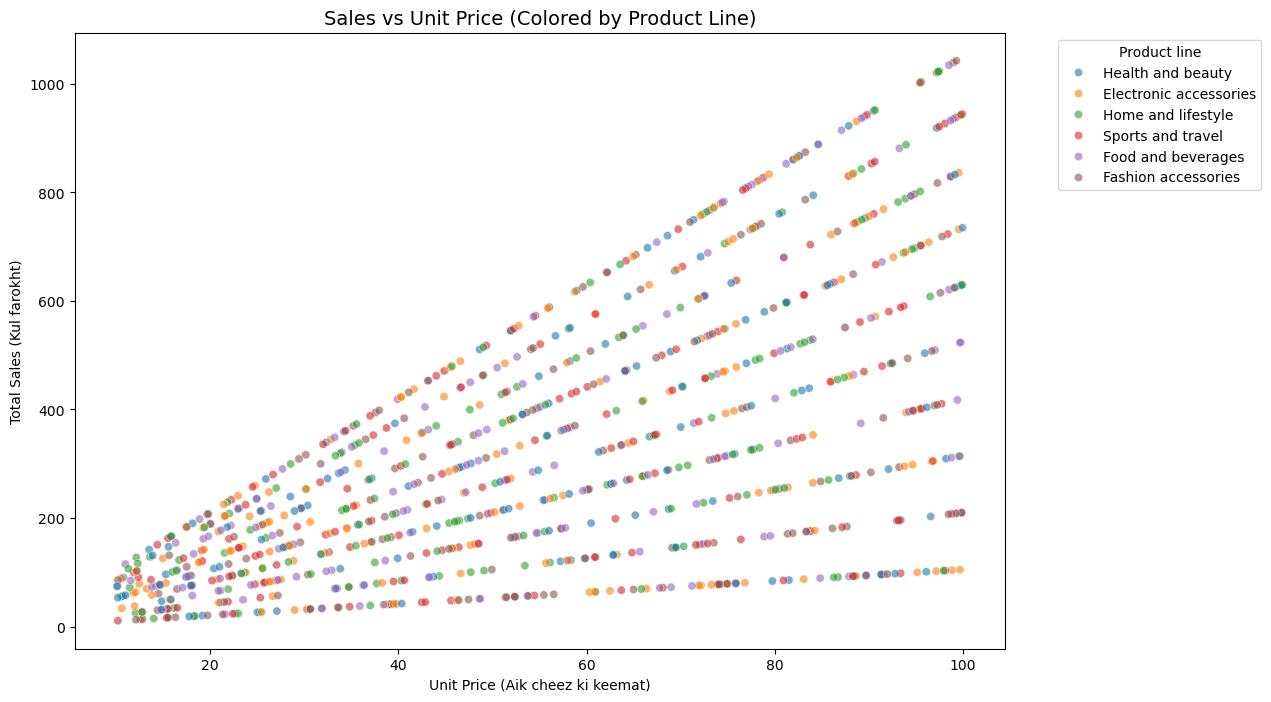

In [7]:
# Plot Sales vs Unit price as a scatterplot, colored by Product line
# sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Product line', alpha=0.6). What pattern do you see?




import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot ka size bara karna taake points saaf dikhein
plt.figure(figsize=(12, 8))

# 2. Scatterplot banana jahan x-axis par Unit Price, y-axis par Sales aur rang Product Line ke mutabiq hon
sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Product line', alpha=0.6)

# 3. Legend ko graph se bahar nikalna taake graph khula dikhe
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Product line')

# 4. Labels aur Title lagana
plt.xlabel('Unit Price (Aik cheez ki keemat)')
plt.ylabel('Total Sales (Kul farokht)')
plt.title('Sales vs Unit Price (Colored by Product Line)', fontsize=14)

plt.show()

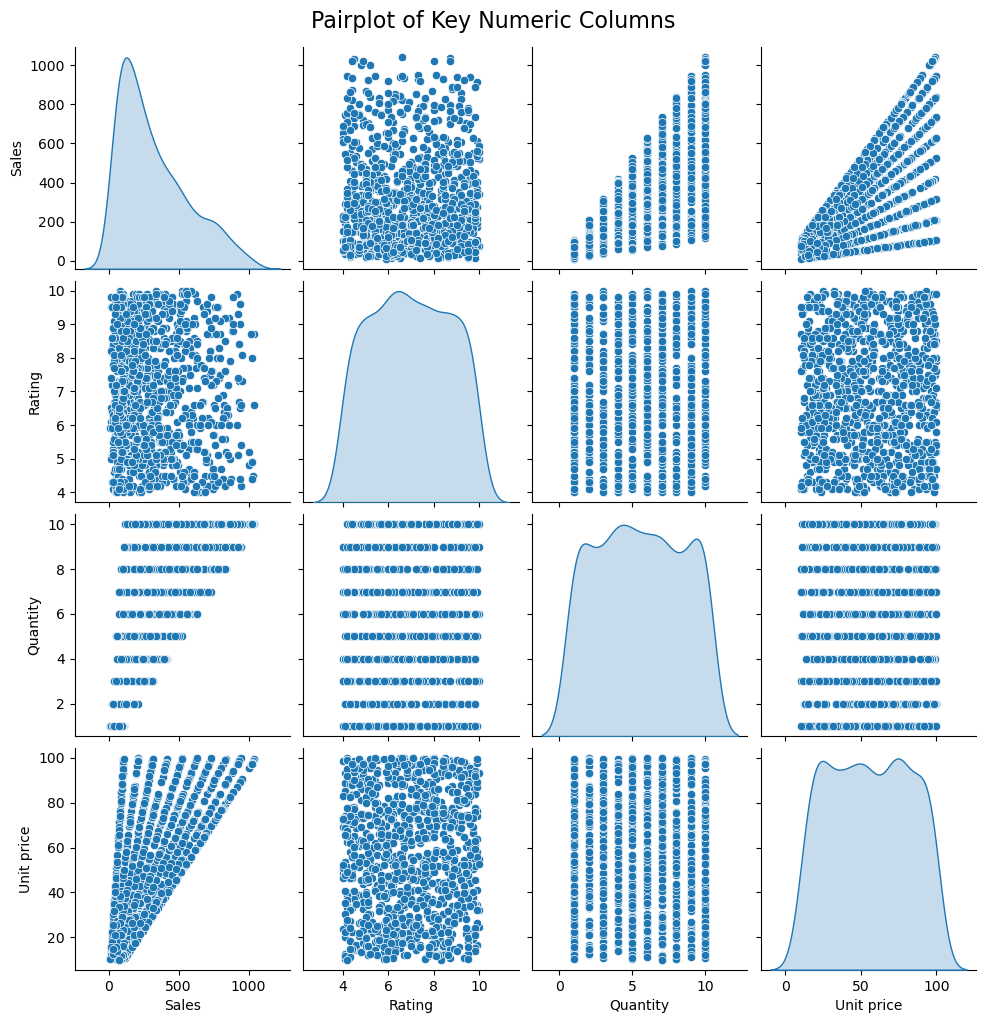

In [8]:

# Build a pairplot on the 4 key numeric columns
# sns.pairplot(df[['Sales','Rating','Quantity','Unit price']], diag_kind='kde'). 
#     This gives you 16 charts at once — look for any obvious patterns.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pairplot banana (4 key numeric columns ka matrix)
# diag_kind='kde' se diagonal par histograms ki jagah smooth curves (curves) banenge
g = sns.pairplot(df[['Sales', 'Rating', 'Quantity', 'Unit price']], diag_kind='kde')

# 2. Title lagana
g.fig.suptitle('Pairplot of Key Numeric Columns', y=1.02, fontsize=16)

plt.show()